In [1]:
import secrets
from typing import Optional
from tqdm import tqdm

import numpy as np

import torch
import torchopt

import nll_to_po.models.dn_policy as Policy
import nll_to_po.models.reward_network as RM
from nll_to_po.training.utils import (
    set_seed_everywhere,
)
import nll_to_po.training.loss as L
import nll_to_po.training.reward as R

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5)
sns.set_palette("colorblind")
sns.despine()

seed = secrets.randbits(32)
set_seed_everywhere(seed)
print(f"Seed: {seed}")

Seed: 3998321466


<Figure size 640x480 with 0 Axes>

### Data utils

In [2]:
def generate_data_linear_noloader(
    input_dim: int,
    output_dim: int,
    train_size: int = 100,
    val_size: int = 100,
    test_size: int = 100,
    init_dist_loc: Optional[float] = None,
    init_dist_scale: Optional[float] = None,
    init_dist_n_samples: int = 1,
    A: Optional[torch.Tensor] = None,
):
    assert input_dim == output_dim, (
        f"input dim {input_dim} is different from output dim {output_dim}"
    )

    # resample parameters
    if A is None:
        A = torch.eye(output_dim)
    if init_dist_loc is None:
        init_dist_loc = np.random.uniform(-6.0, 6.0)
    if init_dist_scale is None:
        init_dist_scale = np.random.uniform(0.1, 2.5)

    # Generate input data (uniform in -5,5)
    X_unique = torch.rand((train_size + val_size + test_size, input_dim)) * 10 - 5

    # For training data: repeat each unique X multiple times
    X_train_unique = X_unique[:train_size]
    X_train = X_train_unique.repeat_interleave(init_dist_n_samples, dim=0)

    # Compute mean for training X and sample multiple y values
    mean_y_train = X_train_unique @ A.T + init_dist_loc
    mean_y_train_expanded = mean_y_train.repeat_interleave(init_dist_n_samples, dim=0)
    y_train = (
        mean_y_train_expanded
        + torch.randn(X_train.shape[0], output_dim) * init_dist_scale
    )
    # std_y_train = torch.full_like(mean_y_train_expanded, init_dist_scale)

    # For validation data: use unique X without repetition
    X_val = X_unique[train_size : train_size + val_size]
    mean_y_val = X_val @ A.T + init_dist_loc
    y_val = mean_y_val + torch.randn(X_val.shape[0], output_dim) * init_dist_scale
    # std_y_val = torch.full_like(mean_y_val, init_dist_scale)

    # For test data: use unique X without repetition
    X_test = X_unique[train_size + val_size :]
    mean_y_test = X_test @ A.T + init_dist_loc
    y_test = mean_y_test + torch.randn(X_test.shape[0], output_dim) * init_dist_scale
    # std_y_test = torch.full_like(mean_y_test, init_dist_scale)

    # Create DataLoaders
    # train_dataset = torch.utils.data.TensorDataset(
    #     X_train, y_train, mean_y_train_expanded, std_y_train
    # )
    # train_dataloader = torch.utils.data.DataLoader(
    #     train_dataset, batch_size=X_train.shape[0], shuffle=True
    # )
    # val_dataset = torch.utils.data.TensorDataset(X_val, y_val, mean_y_val, std_y_val)
    # val_dataloader = torch.utils.data.DataLoader(
    #     val_dataset, batch_size=X_val.shape[0], shuffle=False
    # )
    # test_dataset = torch.utils.data.TensorDataset(
    #     X_test, y_test, mean_y_test, std_y_test
    # )
    # test_dataloader = torch.utils.data.DataLoader(
    #     test_dataset, batch_size=X_test.shape[0], shuffle=False
    # )

    return X_train, y_train, X_val, y_val, X_test, y_test

### Torchopt

In [87]:
# -----------------------
# Helper: make functional params with grad
# -----------------------


def make_functional_with_grads(module):
    params = dict(module.named_parameters())
    params = [p.detach().clone().requires_grad_(True) for _, p in params.items()]
    return module, params


# -----------------------
# Main bilevel routine
# -----------------------
def run_bilevel_optimization_implicit(
    X_train,
    y_train,
    X_val,
    y_val,
    n_outer_epochs=10,
    n_inner_epochs=5,
    inner_lr: float = 1e-3,
    outer_lr: float = 1e-3,
    device: str = "cpu",
    input_dim: int = 2,
    output_dim: int = 2,
    hidden_sizes: list[int] = [64, 64],
    fixed_logstd: bool = False,
    entropy_weight: float = 1.0,
    n_generations: int = 5,
    use_batchnorm: bool = False,
    use_layernorm: bool = False,
    outer_scheduler_patience: int = 0,
    early_stopping_patience: int = 0,
    reward_init_param: float = 1.0,
    reward_use_softplus: bool = False,
):
    # reward
    reward_network = RM.RewardMLPMahalanobisDiag(
        input_dim, init_param=reward_init_param, use_softplus=reward_use_softplus
    ).to(device)
    reward_model, reward_params = make_functional_with_grads(reward_network)

    # reward loss: nll
    nll_loss = L.FuncNLL()

    # Tracking
    outer_losses = []
    val_outer_losses = []
    inner_losses = []
    inner_rewards = []
    U_coeff = []
    U_coeff_grad = []

    # Inner-loop objective function
    # The optimality function: grad(inner_objective)
    def inner_objective(policy_params, reward_params, X, y, policy_model, reward_model):
        reward_params_dict = dict(
            zip(dict(reward_model.named_parameters()).keys(), reward_params)
        )
        reward_fn = R.FuncRewardNetwork(
            reward_model=reward_model, reward_params=reward_params_dict
        )

        # policy loss
        pg_loss = L.FuncPG(
            reward_fn=reward_fn,
            n_generations=n_generations,
            entropy_weight=entropy_weight,
        )

        # Reconstruct params dict (for functional_call)
        policy_params_dict = dict(
            zip(dict(policy_model.named_parameters()).keys(), policy_params)
        )
        loss, _ = pg_loss.compute_loss(
            policy_model=policy_model,
            policy_params=policy_params_dict,
            X=X,
            y=y,
            reward_model=reward_model,
            reward_params=reward_params_dict,
        )
        return loss

    # # inside custom_root
    # def grad_inner_objective(
    #     policy_params, reward_params, X, y
    # ):
    #     loss = inner_objective(policy_params, reward_params, X, y)
    #     grads = torch.autograd.grad(loss, policy_params, create_graph=True)
    #     return grads

    # Optimality Condition is: the gradient w.r.t inner-loop optimal params is 0 (we achieve so by
    # specifying argnums=0 in functorch.grad) the argnums=1 specify which meta-parameter we want to
    # backpropogate, in this case we want to backpropogate to the initial parameters so we set it as 1.
    # You can also set argnums as (1, 2) if you want to backpropogate through multiple meta-parameters

    # Here we pass argnums=1 to the custom_root. That means we want to compute the gradient of
    # optimal_params w.r.t. the 1-indexed argument in inner_solver, i.e., params.
    # torchopt.linear_solve.solve_normal_cg specify that we use the conjugate gradient based linear solver
    @torchopt.diff.implicit.custom_root(
        torch.func.grad(inner_objective, argnums=0),  # optimality function
        argnums=1,
        solve=torchopt.linear_solve.solve_normal_cg(maxiter=50, atol=1e-6),
        # solve=torchopt.linear_solve.solve_inv(ns=True, maxiter=100, alpha=0.1),
    )
    def inner_solver(policy_params, reward_params, X, y, policy_model, reward_model):
        reward_params_dict = dict(
            zip(dict(reward_model.named_parameters()).keys(), reward_params)
        )
        reward_fn = R.FuncRewardNetwork(
            reward_model=reward_model, reward_params=reward_params_dict
        )

        # policy loss
        pg_loss = L.FuncPG(
            reward_fn=reward_fn,
            n_generations=n_generations,
            entropy_weight=entropy_weight,
        )

        def inner_loss_fn(policy_params, X, y):
            # Reconstruct params dict (for functional_call)
            policy_params_dict = dict(
                zip(dict(policy_model.named_parameters()).keys(), policy_params)
            )
            loss, _ = pg_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X,
                y=y,
                reward_model=reward_model,
                reward_params=reward_params_dict,
            )
            return loss

        # Create differentiable SGD optimizer
        inner_optimizer = torchopt.sgd(lr=inner_lr)  # , momentum=0.9)  # , eps=1e-8)
        inner_opt_state = inner_optimizer.init(policy_params)

        # Inner loop with torchopt
        inner_losses_per_iter = []
        inner_rewards_per_iter = []
        for inner_step in range(n_inner_epochs):
            # Compute gradients and update
            grads = torch.func.grad(inner_loss_fn)(
                policy_params,
                X,
                y,
            )
            # Clip gradients to prevent explosion
            grads = [torch.clamp(g, -1.0, 1.0) for g in grads]
            updates, inner_opt_state = inner_optimizer.update(
                grads, inner_opt_state, inplace=False
            )
            policy_params = torchopt.apply_updates(
                policy_params, updates, inplace=False
            )

            # Track loss
            with torch.no_grad():
                # Reconstruct params dict (for functional_call)
                policy_params_dict = dict(
                    zip(dict(policy_model.named_parameters()).keys(), policy_params)
                )
                inner_loss, metrics = pg_loss.compute_loss(
                    policy_model,
                    policy_params_dict,
                    X,
                    y,
                    reward_model=reward_model,
                    reward_params=reward_params_dict,
                )
                inner_losses_per_iter.append(float(inner_loss))
                inner_rewards_per_iter.append(metrics["reward_mean"])
        inner_losses.append(inner_losses_per_iter)
        inner_rewards.append(inner_rewards_per_iter)

        return tuple(policy_params)

    def outer_loss_fn(
        reward_params, policy_params, X, y, X_val, y_val, policy_model, reward_model
    ):
        policy_params = inner_solver(
            policy_params, reward_params, X, y, policy_model, reward_model
        )

        policy_params_dict = dict(
            zip(dict(policy_model.named_parameters()).keys(), policy_params)
        )

        # outer loss
        loss, _ = nll_loss.compute_loss(
            policy_model=policy_model,
            policy_params=policy_params_dict,
            X=X,
            y=y,
        )
        outer_losses.append(float(loss))

        # Validation loss
        with torch.no_grad():
            val_loss, _ = nll_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X_val,
                y=y_val,
            )
            val_outer_losses.append(float(val_loss))
        return loss

    # Learning rate scheduler parameters
    factor = 0.5
    min_lr = 1e-6
    s_patience_counter = 0
    current_outer_lr = outer_lr

    es_patience_counter = 0
    best_val_loss = float("inf")
    best_reward_params = None

    for outer_epoch in tqdm(range(n_outer_epochs), desc="Outer Epochs"):
        # -----------------------
        # Outer loop: update reward params
        # -----------------------

        # Reset reward params gradient
        reward_params = [p.detach().clone().requires_grad_(True) for p in reward_params]

        # reward optimizer with current learning rate
        outer_optimizer = torchopt.adam(lr=current_outer_lr)
        outer_opt_state = outer_optimizer.init(reward_params)

        # Reset policy each outer iteration
        policy = Policy.MLPPolicy(
            input_dim,
            output_dim,
            hidden_sizes,
            fixed_logstd,
            use_batchnorm=use_batchnorm,
            use_layernorm=use_layernorm,
        ).to(device)
        policy_model, policy_params = make_functional_with_grads(policy)

        # Compute gradients and update
        # Here we cant not use torch.func.grad because torchopt is not compatible with torch 2.*
        loss = outer_loss_fn(
            reward_params,
            policy_params,
            X_train.to(device),
            y_train.to(device),
            X_val.to(device),
            y_val.to(device),
            policy_model,
            reward_model,
        )
        grads = torch.autograd.grad(loss, reward_params, create_graph=True)
        # Clip gradients to prevent explosion
        grads = [-torch.clamp(g, -10.0, 10.0) for g in grads]
        updates, outer_opt_state = outer_optimizer.update(
            grads, outer_opt_state, inplace=False
        )

        reward_params = torchopt.apply_updates(reward_params, updates)

        # Early stopping: check if current validation loss is the best
        if not early_stopping_patience:
            U_coeff_grad.append(grads[0].item())
        else:
            current_val_loss = val_outer_losses[-1]
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_reward_params = [p.detach().clone() for p in reward_params]
                es_patience_counter = 0
                U_coeff_grad.append(grads[0].item())
            else:
                es_patience_counter += 1
                reward_params = [p.detach().clone() for p in best_reward_params]
                U_coeff_grad.append(0.0)
                if es_patience_counter >= early_stopping_patience:
                    print(f"Early stopping at outer epoch {outer_epoch}")
                    break

        if outer_scheduler_patience:
            current_val_loss = val_outer_losses[-1]
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                s_patience_counter = 0
            else:
                s_patience_counter += 1
            if (
                s_patience_counter >= outer_scheduler_patience
                and current_outer_lr > min_lr
            ):
                current_outer_lr = max(current_outer_lr * factor, min_lr)

        # track the attribute param of the reward network
        U_coeff.append(reward_params[0].item())

    return (
        outer_losses,
        val_outer_losses,
        inner_losses,
        inner_rewards,
        U_coeff,
        U_coeff_grad,
    )

In [143]:
input_dim: int = 2
output_dim: int = 2

init_dist_loc: float = 6.0
init_dist_scale: float = 1.25
init_dist_n_samples: int = 10
train_size: int = 100
val_size: int = 100

# A: torch.Tensor = torch.randn((output_dim, input_dim))
A: torch.Tensor = torch.eye(output_dim)

X_train, y_train, X_val, y_val, _, _ = generate_data_linear_noloader(
    input_dim=input_dim,
    output_dim=output_dim,
    train_size=train_size,
    val_size=val_size,
    init_dist_loc=init_dist_loc,
    init_dist_scale=init_dist_scale,
    init_dist_n_samples=init_dist_n_samples,
    A=A,
)

# Policy architecture
hidden_sizes: list[int] = [64, 64]
fixed_logstd: bool = False
use_batchnorm: bool = False
use_layernorm: bool = True

# PG
entropy_weight: float = 1.65
n_generations: int = 5

# Reward
reward_init_param: float = 1.0
reward_use_softplus: bool = False

n_outer_epochs: int = 20
n_inner_epochs: int = 50

inner_lr: float = 1e-2
outer_lr: float = 1e-1
outer_scheduler_patience: int = 0
early_stopping_patience: int = 0

device: str = "cuda:0"

U_star = (entropy_weight) / (2 * (init_dist_scale**2))

In [144]:
# Experiment parameters
max_repetitions = 10
max_tolerated_crashes = 10

# Storage for all runs
all_outer_losses = []
all_val_outer_losses = []
all_inner_losses = []
all_inner_rewards = []
all_U_coeff = []
all_U_coeff_grad = []

successful_runs = 0
crashes = 0

for rep in range(max_repetitions):
    if crashes >= max_tolerated_crashes:
        print(
            f"Maximum tolerated crashes ({max_tolerated_crashes}) reached. Stopping experiments."
        )
        break

    try:
        print(f"Running experiment {rep + 1}/{max_repetitions}...")

        # Run the bilevel optimization
        (
            outer_losses,
            val_outer_losses,
            inner_losses,
            inner_rewards,
            U_coeff,
            U_coeff_grad,
        ) = run_bilevel_optimization_implicit(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            n_outer_epochs=n_outer_epochs,
            n_inner_epochs=n_inner_epochs,
            inner_lr=inner_lr,
            outer_lr=outer_lr,
            device=device,
            input_dim=input_dim,
            output_dim=output_dim,
            hidden_sizes=hidden_sizes,
            fixed_logstd=fixed_logstd,
            entropy_weight=entropy_weight,
            n_generations=n_generations,
            use_batchnorm=use_batchnorm,
            use_layernorm=use_layernorm,
            outer_scheduler_patience=outer_scheduler_patience,
            early_stopping_patience=early_stopping_patience,
            reward_init_param=reward_init_param,
            reward_use_softplus=reward_use_softplus,
        )

        # Store results
        all_outer_losses.append(outer_losses)
        all_val_outer_losses.append(val_outer_losses)
        all_inner_losses.append(inner_losses)
        all_inner_rewards.append(inner_rewards)
        all_U_coeff.append(U_coeff)
        all_U_coeff_grad.append(U_coeff_grad)

        successful_runs += 1
        print(f"Experiment {rep + 1} completed successfully.")

    except Exception as e:
        crashes += 1
        print(f"Experiment {rep + 1} crashed: {str(e)}")
        print(f"Crashes so far: {crashes}/{max_tolerated_crashes}")
        continue

print(f"Completed {successful_runs} successful runs out of {max_repetitions} attempts.")

# Convert to numpy arrays for easier computation
all_outer_losses = np.array(all_outer_losses)
all_val_outer_losses = np.array(all_val_outer_losses)
all_U_coeff = np.array(all_U_coeff)
all_U_coeff_grad = np.array(all_U_coeff_grad)

# Flatten inner rewards for averaging
all_inner_rewards_flat = []
for run in all_inner_rewards:
    flat_rewards = []
    for outer_epoch in run:
        flat_rewards.extend(outer_epoch)
    all_inner_rewards_flat.append(flat_rewards)
all_inner_rewards_flat = np.array(all_inner_rewards_flat)

# Compute statistics
outer_losses_mean = np.mean(all_outer_losses, axis=0)
outer_losses_std = np.std(all_outer_losses, axis=0)
outer_losses_se = outer_losses_std / np.sqrt(successful_runs)

val_outer_losses_mean = np.mean(all_val_outer_losses, axis=0)
val_outer_losses_std = np.std(all_val_outer_losses, axis=0)
val_outer_losses_se = val_outer_losses_std / np.sqrt(successful_runs)

U_coeff_mean = np.mean(all_U_coeff, axis=0)
U_coeff_std = np.std(all_U_coeff, axis=0)
U_coeff_se = U_coeff_std / np.sqrt(successful_runs)

U_coeff_grad_mean = np.mean(all_U_coeff_grad, axis=0)
U_coeff_grad_std = np.std(all_U_coeff_grad, axis=0)
U_coeff_grad_se = U_coeff_grad_std / np.sqrt(successful_runs)

inner_rewards_mean = np.mean(all_inner_rewards_flat, axis=0)
inner_rewards_std = np.std(all_inner_rewards_flat, axis=0)
inner_rewards_se = inner_rewards_std / np.sqrt(successful_runs)

Running experiment 1/10...


Outer Epochs:   0%|          | 0/20 [00:00<?, ?it/s]/mnt/data_2/abenechehab/micromamba/envs/nllpo/lib/python3.12/site-packages/torchopt/diff/implicit/decorator.py:123: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vjp` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.vjp` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  _, optimality_cond_vjp_fn, *_ = functorch.vjp(optimality_cond, solution)
/mnt/data_2/abenechehab/micromamba/envs/nllpo/lib/python3.12/site-packages/torchopt/linear_solve/utils.py:49: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vjp` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.vjp` instead; see the PyTorch 2.0 release no

Experiment 1 completed successfully.
Running experiment 2/10...


Outer Epochs: 100%|██████████| 20/20 [00:21<00:00,  1.06s/it]


Experiment 2 completed successfully.
Running experiment 3/10...


...

Experiment 8 completed successfully.
Running experiment 9/10...


Outer Epochs: 100%|██████████| 20/20 [00:22<00:00,  1.13s/it]


Experiment 9 completed successfully.
Running experiment 10/10...


Outer Epochs: 100%|██████████| 20/20 [00:23<00:00,  1.17s/it]

Experiment 10 completed successfully.
Completed 10 successful runs out of 10 attempts.


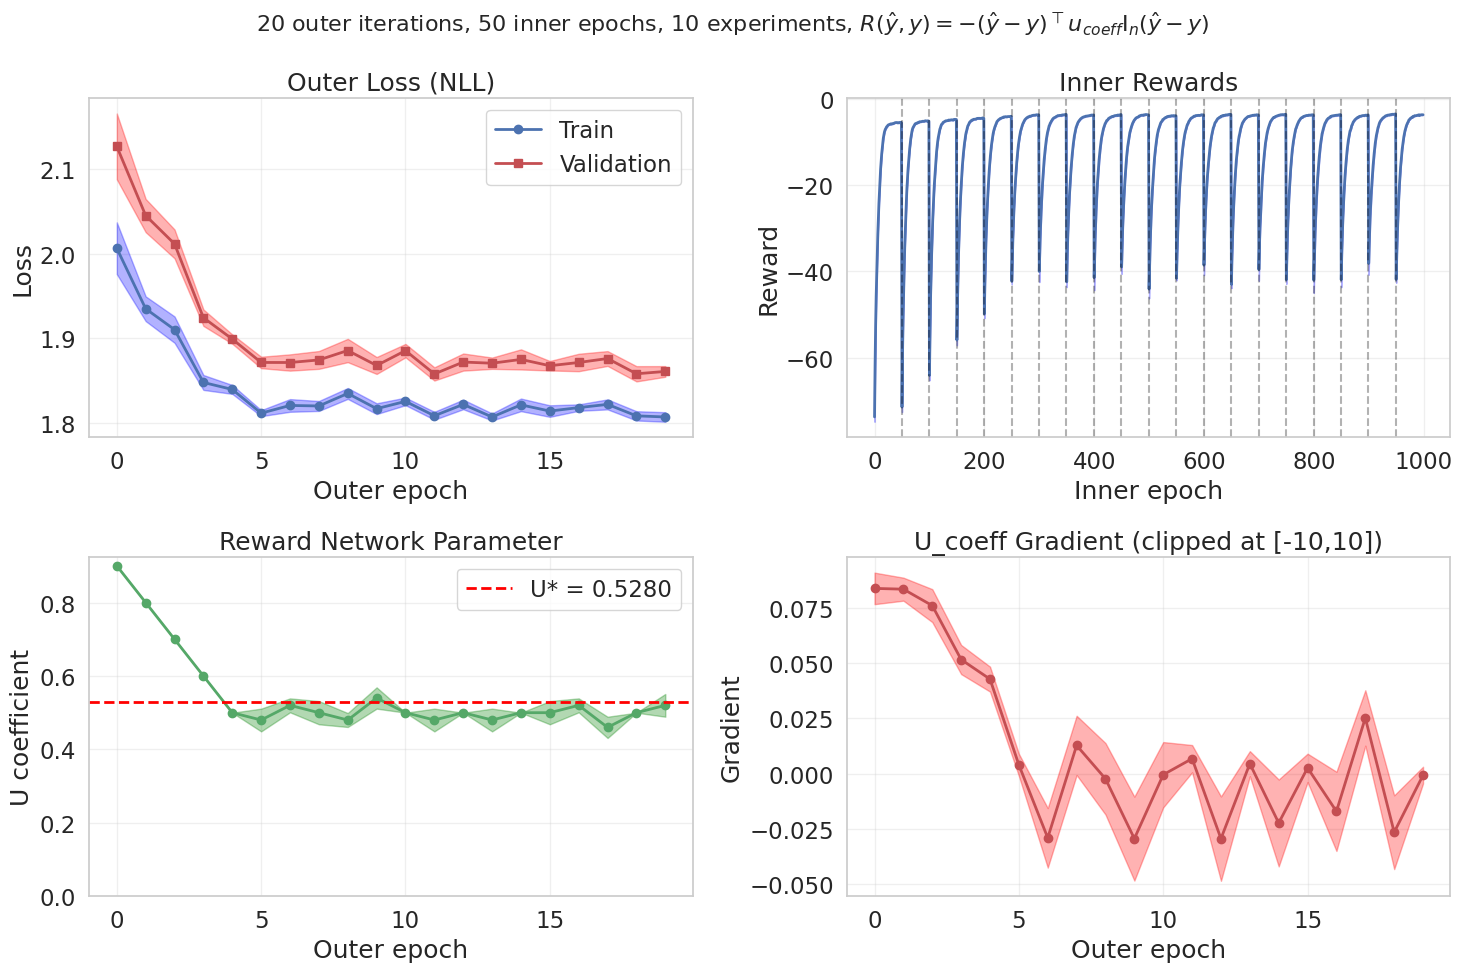


Final statistics after 10 successful runs:
Final U coefficient: 0.5200 ± 0.0310
Target U*: 0.5280
Final outer loss: 1.8066 ± 0.0056


In [145]:
# Plot results with error bars
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot outer losses (train and validation)
epochs_outer = range(len(outer_losses_mean))
ax1.plot(
    epochs_outer, outer_losses_mean, "b-o", linewidth=2, markersize=6, label="Train"
)
ax1.fill_between(
    epochs_outer,
    outer_losses_mean - outer_losses_se,
    outer_losses_mean + outer_losses_se,
    alpha=0.3,
    color="blue",
)
ax1.plot(
    epochs_outer,
    val_outer_losses_mean,
    "r-s",
    linewidth=2,
    markersize=6,
    label="Validation",
)
ax1.fill_between(
    epochs_outer,
    val_outer_losses_mean - val_outer_losses_se,
    val_outer_losses_mean + val_outer_losses_se,
    alpha=0.3,
    color="red",
)
ax1.set_xlabel("Outer epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Outer Loss (NLL)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot inner rewards
epochs_inner = range(len(inner_rewards_mean))
ax2.plot(epochs_inner, inner_rewards_mean, "b-", linewidth=2)
ax2.fill_between(
    epochs_inner,
    inner_rewards_mean - inner_rewards_se,
    inner_rewards_mean + inner_rewards_se,
    alpha=0.3,
    color="blue",
)

# Add vertical dotted lines to separate outer epochs
for i in range(1, n_outer_epochs):
    if i * n_inner_epochs < len(epochs_inner):
        ax2.axvline(
            x=i * n_inner_epochs - 0.5, color="black", linestyle="--", alpha=0.3
        )

ax2.set_xlabel("Inner epoch")
ax2.set_ylabel("Reward")
ax2.set_title("Inner Rewards")
ax2.grid(True, alpha=0.3)
# Set integer ticks for x-axis
# ax2.set_xticks(range(0, len(epochs_inner), max(1, len(epochs_inner)//10)))

# Plot U coefficient
epochs_U = range(len(U_coeff_mean))
if reward_use_softplus:
    ax3.plot(
        epochs_U, np.log(1 + np.exp(U_coeff_mean)), "g-o", linewidth=2, markersize=6
    )
    ax3.fill_between(
        epochs_U,
        np.log(1 + np.exp(U_coeff_mean - U_coeff_se)),
        np.log(1 + np.exp(U_coeff_mean + U_coeff_se)),
        alpha=0.3,
        color="green",
    )
else:
    ax3.plot(epochs_U, U_coeff_mean, "g-o", linewidth=2, markersize=6)
    ax3.fill_between(
        epochs_U,
        U_coeff_mean - U_coeff_se,
        U_coeff_mean + U_coeff_se,
        alpha=0.3,
        color="green",
    )
ax3.axhline(
    y=U_star, color="red", linestyle="--", linewidth=2, label=f"U* = {U_star:.4f}"
)
ax3.set_xlabel("Outer epoch")
ax3.set_ylabel("U coefficient")
ax3.set_title("Reward Network Parameter")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(bottom=0)

# Plot U coefficient gradients
epochs_U = range(len(U_coeff_grad_mean))
ax4.plot(epochs_U, U_coeff_grad_mean, "r-o", linewidth=2, markersize=6)
ax4.fill_between(
    epochs_U,
    U_coeff_grad_mean - U_coeff_grad_se,
    U_coeff_grad_mean + U_coeff_grad_se,
    alpha=0.3,
    color="red",
)
ax4.set_xlabel("Outer epoch")
ax4.set_ylabel("Gradient")
ax4.set_title("U_coeff Gradient (clipped at [-10,10])")
ax4.grid(True, alpha=0.3)

suptitle = f"{n_outer_epochs} outer iterations, {n_inner_epochs} inner epochs, {max_repetitions} experiments, "
suptitle += r"$R(\hat{y},y) = -(\hat{y}-y)^\top u_{coeff} \mathrm{I}_n (\hat{y}-y)$"

fig.suptitle(
    suptitle,
    fontsize=16,
    y=0.98,
)

plt.tight_layout()
plt.show()

print(f"\nFinal statistics after {successful_runs} successful runs:")
print(f"Final U coefficient: {U_coeff_mean[-1]:.4f} ± {U_coeff_se[-1]:.4f}")
print(f"Target U*: {U_star:.4f}")
print(f"Final outer loss: {outer_losses_mean[-1]:.4f} ± {outer_losses_se[-1]:.4f}")